# ⚡ ELECTRO-VOLT — Clasificación de fallos eléctricos con Machine Learning

**Proyecto Integrador · Maestría en IA · UEES**

Este notebook recorre todo el camino, de principio a fin:

1. Cargar los datos
2. Entenderlos y armar las clases de estado
3. Justificar el ajuste de clases (LLL y LLLG se unen en una sola)
4. Entrenar 3 modelos (Regresión Logística, Random Forest y SVM) y compararlos
5. Medir qué tan bien funciona el modelo final (métricas contra las metas SMART)
6. Explicar sus decisiones (SHAP)
7. Guardar el modelo para que la interfaz web lo use

**Cómo usarlo:** ejecuta las celdas en orden (menú *Entorno de ejecución → Ejecutar todo*). Cada sección tiene una explicación en lenguaje sencillo.

**Equivalencia con los notebooks del repositorio:** secciones 1–3 → `01_exploracion` y `02_preprocesamiento` · secciones 4–7 → `03_modelado`.

## 0. Preparación
La primera celda instala **SHAP** (la librería de IA explicable). Solo hay que ejecutarla una vez por sesión de Colab; tarda unos segundos.

In [ ]:
%pip install -q shap

In [ ]:
import os, time, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, recall_score, classification_report, confusion_matrix

warnings.filterwarnings("ignore")
SEMILLA = 42          # número fijo para que los resultados sean siempre los mismos
sns.set_theme(style="whitegrid")
print("Librerías listas ✅")

Librerías listas ✅


## 1. Cargar los datos
Usamos el archivo **`classData.csv`** de Kaggle (*Electrical Fault Detection and Classification*).

La celda busca el archivo en el entorno; si no lo encuentra, te abre un botón para **subirlo desde tu computador**.

In [ ]:
CANDIDATAS = ["classData.csv", "data/classData.csv", "../data/classData.csv"]
ruta = next((r for r in CANDIDATAS if os.path.exists(r)), None)

if ruta is None:
    from google.colab import files
    print("👉 Selecciona el archivo classData.csv de tu computador")
    subido = files.upload()
    ruta = list(subido.keys())[0]

df = pd.read_csv(ruta)
print("Archivo:", ruta)
print("Filas y columnas:", df.shape)
df.head()

👉 Selecciona el archivo classData.csv de tu computador


Saving classData.csv to classData.csv
Archivo: classData.csv
Filas y columnas: (7861, 10)


,G,C,B,A,Ia,Ib,Ic,Va,Vb,Vc
0,1,0,0,1,-151.291812,-9.677452,85.800162,0.400750,-0.132935,-0.267815
1,1,0,0,1,-336.186183,-76.283262,18.328897,0.312732,-0.123633,-0.189099
2,1,0,0,1,-502.891583,-174.648023,-80.924663,0.265728,-0.114301,-0.151428
3,1,0,0,1,-593.941905,-217.703359,-124.891924,0.235511,-0.104940,-0.130570
4,1,0,0,1,-643.663617,-224.159427,-132.282815,0.209537,-0.095554,-0.113983


## 2. Entender los datos y armar las clases

Cada fila es una lectura del sistema eléctrico:

| Columnas | Qué son |
|---|---|
| `Ia, Ib, Ic` | Corrientes de las fases A, B, C |
| `Va, Vb, Vc` | Voltajes de las fases A, B, C (en por unidad) |
| `G, C, B, A` | Cuatro banderas (0/1) que indican **qué tipo de falla ocurrió** |

Las banderas `G, C, B, A` combinadas forman la **etiqueta** que queremos que el modelo aprenda a predecir. Primero las convertimos a las 6 clases originales del dataset (`clase_6`).

Valores nulos: 0
Filas duplicadas: 0

Muestras por clase original:
 clase_6
Normal    2365
LG        1129
LL        1004
LLG       1134
LLL       1096
LLLG      1133
Name: count, dtype: int64


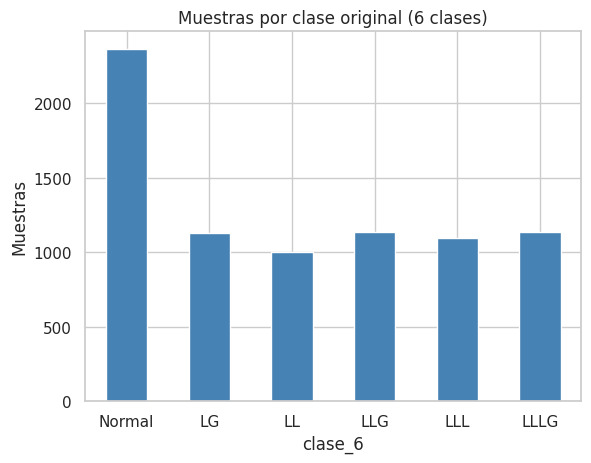


⚠️ El archivo viene ORDENADO por clase (6 bloques seguidos). Por eso siempre hay que mezclar los datos al dividirlos (train_test_split y KFold con shuffle lo hacen).


In [ ]:
print("Valores nulos:", int(df.isna().sum().sum()))
print("Filas duplicadas:", int(df.duplicated().sum()))

MAPA_6 = {
    (0, 0, 0, 0): "Normal",
    (1, 0, 0, 1): "LG",    # Línea a tierra
    (0, 1, 1, 0): "LL",    # Línea a línea
    (1, 0, 1, 1): "LLG",   # Doble línea a tierra
    (0, 1, 1, 1): "LLL",   # Trifásico
    (1, 1, 1, 1): "LLLG",  # Trifásico a tierra
}
df["clase_6"] = [MAPA_6[tuple(fila)] for fila in df[["G", "C", "B", "A"]].values]
ORDEN_6 = ["Normal", "LG", "LL", "LLG", "LLL", "LLLG"]

conteo = df["clase_6"].value_counts().reindex(ORDEN_6)
print("\nMuestras por clase original:\n", conteo)
conteo.plot(kind="bar", color="steelblue", title="Muestras por clase original (6 clases)")
plt.ylabel("Muestras"); plt.xticks(rotation=0); plt.show()

bloques = int((df["clase_6"] != df["clase_6"].shift()).sum())
print(f"\n⚠️ El archivo viene ORDENADO por clase ({bloques} bloques seguidos). "
      "Por eso siempre hay que mezclar los datos al dividirlos (train_test_split y KFold con shuffle lo hacen).")

COLUMNAS = ["Va", "Vb", "Vc", "Ia", "Ib", "Ic"]

## 3. Ajuste de clases: LLL y LLLG se identifican como una sola "falla trifásica"

> ### 📌 Justificación del ajuste (para la docente)
>
> **Qué se cambió:** el dataset trae 6 clases (Normal, LG, LL, LLG, LLL, LLLG). En este proyecto **LLL (trifásica) y LLLG (trifásica a tierra) se unen en una sola clase: `Trifásica`**. El modelo final clasifica **5 estados**: Normal, LG, LL, LLG y Trifásica.
>
> **Por qué (razón física):** en una falla trifásica balanceada las tres corrientes de falla son iguales en magnitud y están a 120° entre sí, por lo que se cancelan en el punto de conexión a tierra. La conexión a tierra **no lleva corriente** y los voltajes y corrientes de fase quedan igual con o sin tierra. Con las 6 señales disponibles (Va, Vb, Vc, Ia, Ib, Ic) ambas fallas son **eléctricamente indistinguibles**. Además, la protección de fase las despeja de la misma manera, así que la acción operativa es la misma.
>
> **Por qué (evidencia en los datos):** la celda siguiente entrena un modelo solo para separar LLL de LLLG con las 6 señales. Si el resultado es cercano al azar, queda demostrado que **la información no está en los datos**, y no es una debilidad del algoritmo.
>
> **Alternativa descartada:** se podría separar ambas clases con la suma `Ia + Ib + Ic` (corriente residual), y el modelo llegaría a ≈ 0.99. Pero esa separación se apoya en una diferencia mínima (≈ 2 A en LLL contra 0.00 A en LLLG) que parece provenir de la **simulación** y no de un fenómeno físico que se repita en una red real. Se decidió no construir el modelo sobre ese artefacto.
>
> **Qué hace la aplicación:** ante una trifásica muestra *"Falla trifásica. Con estas señales no se distingue si involucra tierra; verificar con la medición de neutro/tierra."*

In [ ]:
# Evidencia: ¿se pueden separar LLL y LLLG con las 6 señales?
sub = df[df["clase_6"].isin(["LLL", "LLLG"])]
X_a, X_b, y_a, y_b = train_test_split(sub[COLUMNAS], sub["clase_6"], test_size=0.20,
                                      stratify=sub["clase_6"], random_state=SEMILLA)
rf_prueba = RandomForestClassifier(n_estimators=100, random_state=SEMILLA, class_weight="balanced").fit(X_a, y_a)
acc_lll = accuracy_score(y_b, rf_prueba.predict(X_b))
azar = y_b.value_counts(normalize=True).max()
print(f"Accuracy separando LLL vs LLLG con las 6 señales: {acc_lll:.3f}")
print(f"Accuracy de un modelo que siempre responde la clase más común: {azar:.3f}")
print("\n👉 Si ambos valores son parecidos, el modelo no logra distinguirlas mejor que el azar.")

Accuracy separando LLL vs LLLG con las 6 señales: 0.520
Accuracy de un modelo que siempre responde la clase más común: 0.509

👉 Si ambos valores son parecidos, el modelo no logra distinguirlas mejor que el azar.


Muestras por clase (5 clases):
 clase
Normal       2365
LG           1129
LL           1004
LLG          1134
Trifásica    2229
Name: count, dtype: int64


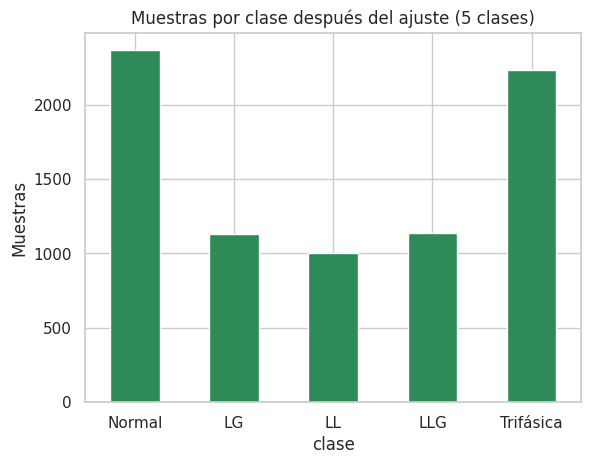

In [ ]:
# Se aplica el ajuste: LLL y LLLG pasan a ser una sola clase
df["clase"] = df["clase_6"].replace({"LLL": "Trifásica", "LLLG": "Trifásica"})
ORDEN_CLASES = ["Normal", "LG", "LL", "LLG", "Trifásica"]

conteo5 = df["clase"].value_counts().reindex(ORDEN_CLASES)
print("Muestras por clase (5 clases):\n", conteo5)
conteo5.plot(kind="bar", color="seagreen", title="Muestras por clase después del ajuste (5 clases)")
plt.ylabel("Muestras"); plt.xticks(rotation=0); plt.show()

## 4. Entrenar y comparar modelos

**Paso a paso:**
- Separamos **80 % de los datos para entrenar** y **20 % para probar** (datos que el modelo nunca vio). `stratify` mantiene la proporción de cada clase.
- Entrenamos 3 modelos: **Regresión Logística** (punto de comparación simple), **Random Forest** (modelo principal) y **SVM** (modelo de comparación). Los tres usan `class_weight="balanced"` para no favorecer a las clases más frecuentes.
- La **brecha (gap)** es *accuracy de entrenamiento − accuracy de prueba*. Si es grande, el modelo memorizó en vez de aprender (*overfitting*).

In [ ]:
X = df[COLUMNAS]
y = df["clase"]
idx_ent, idx_pru = train_test_split(df.index, test_size=0.20, stratify=y, random_state=SEMILLA)
X_ent, X_pru, y_ent, y_pru = X.loc[idx_ent], X.loc[idx_pru], y.loc[idx_ent], y.loc[idx_pru]
print("Muestras de entrenamiento:", len(X_ent), "| de prueba:", len(X_pru))

def crear_modelos():
    return {
        "Regresión Logística": make_pipeline(StandardScaler(),
            LogisticRegression(max_iter=2000, class_weight="balanced")),
        "Random Forest": RandomForestClassifier(n_estimators=100, random_state=SEMILLA,
            class_weight="balanced"),
        "SVM (RBF)": make_pipeline(StandardScaler(),
            SVC(kernel="rbf", C=10, gamma="scale", class_weight="balanced",
                probability=True, random_state=SEMILLA)),
    }

resultados, modelos = [], {}
for nombre, modelo in crear_modelos().items():
    t0 = time.time()
    modelo.fit(X_ent, y_ent)
    t_ent = time.time() - t0
    p_ent, p_pru = modelo.predict(X_ent), modelo.predict(X_pru)
    resultados.append({
        "Modelo": nombre,
        "Acc. entrenamiento": accuracy_score(y_ent, p_ent),
        "Acc. prueba": accuracy_score(y_pru, p_pru),
        "Brecha (gap)": accuracy_score(y_ent, p_ent) - accuracy_score(y_pru, p_pru),
        "F1 macro (prueba)": f1_score(y_pru, p_pru, average="macro"),
        "Tiempo entrenamiento (s)": t_ent,
    })
    modelos[nombre] = modelo

tabla = pd.DataFrame(resultados)
tabla.round(3)

Muestras de entrenamiento: 6288 | de prueba: 1573


,Modelo,Acc. entrenamiento,Acc. prueba,Brecha (gap),F1 macro (prueba),Tiempo entrenamiento (s)
0,Regresión Logística,0.260,0.250,0.009,0.253,0.063
1,Random Forest,1.000,0.999,0.001,0.999,1.612
2,SVM (RBF),0.981,0.981,0.000,0.979,1.755


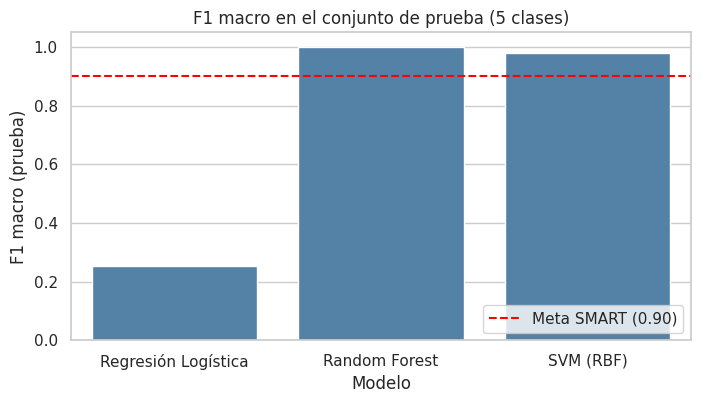

In [ ]:
plt.figure(figsize=(8, 4))
sns.barplot(data=tabla, x="Modelo", y="F1 macro (prueba)", color="steelblue")
plt.axhline(0.90, color="red", ls="--", label="Meta SMART (0.90)")
plt.ylim(0, 1.05); plt.legend(loc="lower right")
plt.title("F1 macro en el conjunto de prueba (5 clases)")
plt.show()

### Validación cruzada (K-Fold, k = 5)
Para asegurarnos de que el resultado **no depende de una sola división** de los datos, repetimos el entrenamiento 5 veces con distintos pedazos y promediamos.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA)
for nombre in ["Random Forest", "SVM (RBF)"]:
    puntajes = cross_val_score(crear_modelos()[nombre], X, y, cv=cv, scoring="f1_macro")
    print(f"{nombre}: F1 macro = {puntajes.mean():.3f} ± {puntajes.std():.3f}   (5 pliegues: {np.round(puntajes, 3)})")

Random Forest: F1 macro = 0.999 ± 0.001   (5 pliegues: [1.    1.    0.999 0.997 0.999])
SVM (RBF): F1 macro = 0.977 ± 0.004   (5 pliegues: [0.982 0.979 0.973 0.981 0.972])


## 5. Métricas del modelo final (Random Forest)
Se elige **Random Forest** como modelo final por ser el modelo principal definido en la ficha técnica. Aquí se compara contra las **metas SMART** del proyecto.

              precision    recall  f1-score   support

      Normal      1.000     0.998     0.999       473
          LG      0.996     1.000     0.998       226
          LL      1.000     1.000     1.000       201
         LLG      1.000     0.996     0.998       227
   Trifásica      0.998     1.000     0.999       446

    accuracy                          0.999      1573
   macro avg      0.999     0.999     0.999      1573
weighted avg      0.999     0.999     0.999      1573



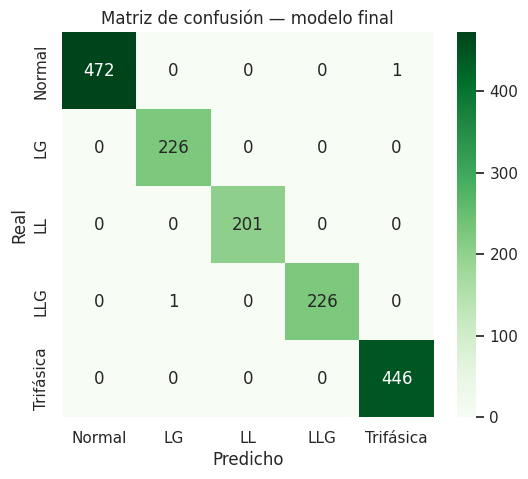

In [ ]:
rf = modelos["Random Forest"]
pred = rf.predict(X_pru)

print(classification_report(y_pru, pred, labels=ORDEN_CLASES, digits=3))

cm = confusion_matrix(y_pru, pred, labels=ORDEN_CLASES)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=ORDEN_CLASES, yticklabels=ORDEN_CLASES)
plt.title("Matriz de confusión — modelo final"); plt.xlabel("Predicho"); plt.ylabel("Real")
plt.show()

In [ ]:
acc = accuracy_score(y_pru, pred)
f1m = f1_score(y_pru, pred, average="macro")
recall_min = recall_score(y_pru, pred, average=None, labels=ORDEN_CLASES).min()

# Latencia: tiempo que tarda UNA predicción
uno = X_pru.iloc[[0]]
n = 100
t0 = time.time()
for _ in range(n):
    rf.predict_proba(uno)
lat_ms = (time.time() - t0) / n * 1000

# Throughput: muestras por segundo al predecir en lote
t0 = time.time(); rf.predict(X_pru); t_lote = time.time() - t0
muestras_seg = len(X_pru) / t_lote

t_ent_final = tabla.loc[tabla["Modelo"] == "Random Forest", "Tiempo entrenamiento (s)"].iloc[0]

metas = [
    ("Accuracy ≥ 0.90",                       f"{acc:.3f}",             acc >= 0.90),
    ("F1 macro ≥ 0.90",                       f"{f1m:.3f}",             f1m >= 0.90),
    ("Recall mínimo por clase ≥ 0.85",        f"{recall_min:.3f}",      recall_min >= 0.85),
    ("Latencia por predicción < 100 ms",      f"{lat_ms:.1f} ms",       lat_ms < 100),
    ("Throughput ≥ 500 muestras/s",           f"{muestras_seg:,.0f}/s", muestras_seg >= 500),
    ("Tiempo de entrenamiento < 5 min",       f"{t_ent_final:.1f} s",   t_ent_final < 300),
]
resumen = pd.DataFrame(metas, columns=["Meta SMART", "Resultado", "¿Cumple?"])
resumen["¿Cumple?"] = resumen["¿Cumple?"].map({True: "✅ Sí", False: "❌ No"})
resumen

,Meta SMART,Resultado,¿Cumple?
0,Accuracy ≥ 0.90,0.999,✅ Sí
1,F1 macro ≥ 0.90,0.999,✅ Sí
2,Recall mínimo por clase ≥ 0.85,0.996,✅ Sí
3,Latencia por predicción < 100 ms,8.2 ms,✅ Sí
4,Throughput ≥ 500 muestras/s,"77,725/s",✅ Sí
5,Tiempo de entrenamiento < 5 min,1.6 s,✅ Sí


## 6. IA Explicable con SHAP
SHAP responde: **¿cuánto empujó cada variable a esta predicción?** Un valor alto significa que esa variable fue muy importante para decidir la clase.

- **Gráfico global:** qué variables importan más en general.
- **Mapa por clase:** qué variables importan para reconocer cada tipo de falla.
- **Una muestra concreta:** por qué el modelo diagnosticó *esa* falla (esto es lo que verá el operador en la app).

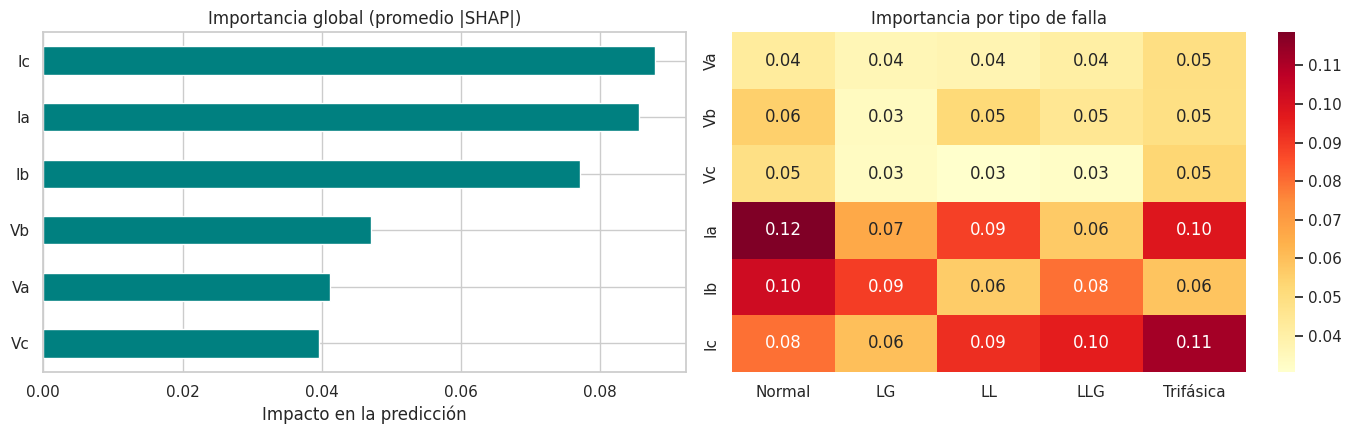

In [ ]:
def normalizar_shap(sv, n_muestras, n_vars, n_clases):
    """Devuelve un arreglo (muestras, variables, clases) sin importar la versión de SHAP."""
    if isinstance(sv, list):
        sv = np.stack(sv, axis=-1)
    sv = np.asarray(sv)
    if sv.shape == (n_muestras, n_vars, n_clases):
        return sv
    if sv.shape == (n_clases, n_muestras, n_vars):
        return np.transpose(sv, (1, 2, 0))
    raise ValueError(f"Forma inesperada de valores SHAP: {sv.shape}")

try:
    import shap
    CLASES = list(rf.classes_)
    muestra = X_pru.sample(100, random_state=SEMILLA)          # 100 muestras para que sea rápido
    explicador = shap.TreeExplainer(rf)
    sv = normalizar_shap(explicador.shap_values(muestra), len(muestra), len(COLUMNAS), len(CLASES))

    imp = pd.DataFrame(np.abs(sv).mean(axis=0), index=COLUMNAS, columns=CLASES)

    fig, ejes = plt.subplots(1, 2, figsize=(14, 4.5))
    imp.mean(axis=1).sort_values().plot(kind="barh", color="teal", ax=ejes[0])
    ejes[0].set_title("Importancia global (promedio |SHAP|)"); ejes[0].set_xlabel("Impacto en la predicción")
    sns.heatmap(imp.loc[:, ORDEN_CLASES], annot=True, fmt=".2f", cmap="YlOrRd", ax=ejes[1])
    ejes[1].set_title("Importancia por tipo de falla")
    plt.tight_layout(); plt.show()
    SHAP_OK = True
except ImportError:
    SHAP_OK = False
    print("SHAP no está instalado: ejecuta la celda de la sección 0. Mientras tanto, importancia del Random Forest:")
    print(pd.Series(rf.feature_importances_, index=COLUMNAS).sort_values(ascending=False).round(3))

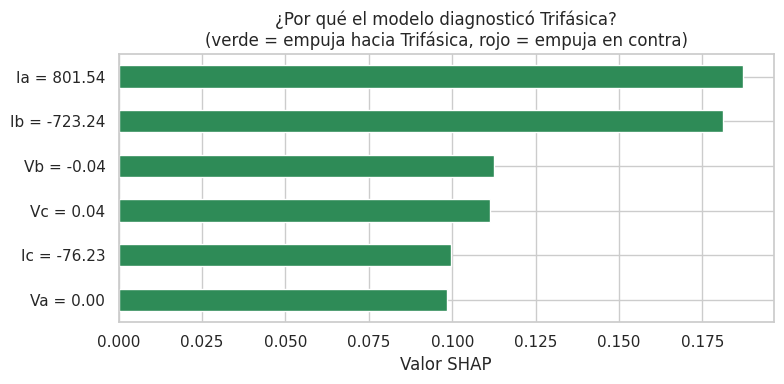

In [ ]:
# Explicación de UNA muestra concreta (ejemplo: una falla trifásica de la parte de prueba)
if SHAP_OK:
    i_real = y_pru[y_pru == "Trifásica"].index[0]
    fila = X_pru.loc[[i_real]]
    clase_pred = rf.predict(fila)[0]
    idx_c = CLASES.index(clase_pred)
    sv_uno = normalizar_shap(explicador.shap_values(fila), 1, len(COLUMNAS), len(CLASES))[0, :, idx_c]

    serie = pd.Series(sv_uno, index=[f"{c} = {fila.iloc[0][c]:.2f}" for c in COLUMNAS]).sort_values()
    colores = ["firebrick" if v < 0 else "seagreen" for v in serie.values]
    serie.plot(kind="barh", color=colores, figsize=(8, 4))
    plt.title(f"¿Por qué el modelo diagnosticó {clase_pred}?\n(verde = empuja hacia {clase_pred}, rojo = empuja en contra)")
    plt.xlabel("Valor SHAP"); plt.tight_layout(); plt.show()

## 7. Guardar el modelo para la interfaz web
Guardamos un **paquete** con el modelo y la información que la app necesita, más un archivo con **ejemplos de prueba** y las **métricas** en JSON.

La función **`predecir_falla(...)`** recibe las 6 lecturas y devuelve el diagnóstico, la confianza, las probabilidades de cada clase y un **mensaje para el operador**. Para la clase `Trifásica` el mensaje aclara que no se distingue si involucra tierra.

In [ ]:
MENSAJES_OPERADOR = {
    "Normal":    "Operación normal. No se detecta falla.",
    "LG":        "Falla de línea a tierra.",
    "LL":        "Falla de línea a línea.",
    "LLG":       "Falla de doble línea a tierra.",
    "Trifásica": ("Falla trifásica. Con las señales de fase no se distingue si involucra tierra "
                  "(LLL o LLLG); verificar con la medición de neutro/tierra."),
}

NOTA_CLASES = ("LLL y LLLG se unieron en una sola clase 'Trifásica' porque en una falla trifásica "
               "balanceada la conexión a tierra no lleva corriente y las señales de fase son las mismas.")

PAQUETE = {
    "modelo": rf,
    "columnas": COLUMNAS,                 # orden exacto de las variables
    "clases": list(rf.classes_),
    "mensajes_operador": MENSAJES_OPERADOR,
    "nota_clases": NOTA_CLASES,
    "descripcion": "Random Forest (100 árboles) con 6 lecturas trifásicas, 5 clases",
}
joblib.dump(PAQUETE, "modelo_fallos_rf.joblib", compress=3)

metricas = {
    "modelo": "Random Forest",
    "clases": ORDEN_CLASES,
    "variables_entrada": COLUMNAS,
    "accuracy_prueba": round(float(acc), 4),
    "f1_macro_prueba": round(float(f1m), 4),
    "recall_minimo_por_clase": round(float(recall_min), 4),
    "latencia_ms": round(float(lat_ms), 2),
    "nota_clases": NOTA_CLASES,
}
with open("metricas.json", "w", encoding="utf-8") as f:
    json.dump(metricas, f, indent=2, ensure_ascii=False)

# 3 ejemplos reales de prueba por clase (solo las 6 lecturas), para probar la interfaz
ejemplos = (df.loc[idx_pru].groupby("clase").head(3)[COLUMNAS + ["clase"]]
              .sort_values("clase").reset_index(drop=True))
ejemplos.to_csv("ejemplos_prueba.csv", index=False)

print("Archivos generados:", [a for a in ["modelo_fallos_rf.joblib", "metricas.json", "ejemplos_prueba.csv"] if os.path.exists(a)])
print("Tamaño del modelo: %.1f MB" % (os.path.getsize("modelo_fallos_rf.joblib") / 1e6))

Archivos generados: ['modelo_fallos_rf.joblib', 'metricas.json', 'ejemplos_prueba.csv']
Tamaño del modelo: 0.6 MB


In [ ]:
def predecir_falla(Va, Vb, Vc, Ia, Ib, Ic, paquete=None):
    """Recibe las 6 lecturas y devuelve diagnóstico, confianza, probabilidades y mensaje para el operador."""
    paquete = paquete or joblib.load("modelo_fallos_rf.joblib")
    fila = pd.DataFrame([{"Va": Va, "Vb": Vb, "Vc": Vc, "Ia": Ia, "Ib": Ib, "Ic": Ic}])[paquete["columnas"]]
    modelo = paquete["modelo"]
    probs = modelo.predict_proba(fila)[0]
    k = int(np.argmax(probs))
    diag = str(modelo.classes_[k])
    return {
        "diagnostico": diag,
        "confianza": round(float(probs[k]), 4),
        "probabilidades": {str(c): round(float(p), 4) for c, p in zip(modelo.classes_, probs)},
        "mensaje_operador": paquete["mensajes_operador"][diag],
    }

# Prueba: una muestra de cada clase tomada del archivo de ejemplos
paquete_cargado = joblib.load("modelo_fallos_rf.joblib")
for _, r in ejemplos.groupby("clase").head(1).iterrows():
    res = predecir_falla(r["Va"], r["Vb"], r["Vc"], r["Ia"], r["Ib"], r["Ic"], paquete_cargado)
    print(f"Real: {r['clase']:<10} → Diagnóstico: {res['diagnostico']:<10} (confianza {res['confianza']:.0%})")
print("\nEjemplo de mensaje para la interfaz:\n", res["mensaje_operador"])

Real: LG         → Diagnóstico: LG         (confianza 100%)
Real: LL         → Diagnóstico: LL         (confianza 83%)
Real: LLG        → Diagnóstico: LLG        (confianza 100%)
Real: Normal     → Diagnóstico: Normal     (confianza 100%)
Real: Trifásica  → Diagnóstico: Trifásica  (confianza 99%)

Ejemplo de mensaje para la interfaz:
 Falla trifásica. Con las señales de fase no se distingue si involucra tierra (LLL o LLLG); verificar con la medición de neutro/tierra.


In [ ]:
# Solo en Google Colab: descarga los 3 archivos a tu computador para pasárselos a tu compañero
try:
    from google.colab import files
    for a in ["modelo_fallos_rf.joblib", "metricas.json", "ejemplos_prueba.csv"]:
        files.download(a)
except ImportError:
    print("(No estás en Colab: los archivos quedaron en la carpeta actual.)")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
### ✅ Cierre
- El modelo final clasifica **5 estados**: Normal, LG, LL, LLG y Trifásica (LLL/LLLG).
- LLL y LLLG se unieron porque, con las señales de fase disponibles, **son eléctricamente indistinguibles** (la conexión a tierra no lleva corriente en una falla trifásica balanceada). Esto se verificó con los datos en la sección 3.
- Se descartó separarlas con la corriente residual (`Ia+Ib+Ic`) porque esa diferencia (≈ 2 A contra 0.00 A) parece un efecto de la simulación.
- Los datos son **simulados** (MATLAB/Simulink): conviene declararlo como limitación y, si se puede, validar con el dataset alternativo (Mendeley).